<a href="https://colab.research.google.com/github/brhan29/makemore/blob/main/makemore_p2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from urllib.request import urlretrieve
urlretrieve(
    "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt",
    "names.txt"
)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:3]

['emma', 'olivia', 'ava']

In [4]:
chars = sorted(set(''.join(words)))
stoi = {s:(i+1) for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [5]:
import random
random.seed(42)
random.shuffle(words)

# context window
cwin = 3

def build_dataset(words):
  X, Y = [], []
  for word in words:
    curcontext = [0] * cwin
    for ch in word + '.':
      X.append(curcontext)
      Y.append(stoi[ch])
      curcontext = curcontext[1:] + [stoi[ch]]
  return torch.tensor(X), torch.tensor(Y)

# # Just testing stuff
# X, Y = build_dataset(words[:3])
# for i in range(len(X)):
#   print(X[i], Y[i])

# 80/10/10 training/val/test split
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
Xtr,Ytr = build_dataset(words[:n1])
Xval,Yval = build_dataset(words[n1:n2])
Xtest,Ytest = build_dataset(words[n2:])

In [6]:
# Initialize parameters
# Embedding dimensions, hidden neuron count
edim = 5
hidn = 100
batchsize = 300
lr = 0.1
g = torch.Generator().manual_seed(2147483647)
C0 = torch.randn((27, edim), generator=g)
W10 = torch.randn((edim * cwin, hidn), generator=g)
b10 = torch.randn(hidn, generator=g)
W20 = torch.randn((hidn, 27), generator=g)
b20 = torch.randn(27, generator=g)
C = C0
W1 = W10
b1 = b10
W2 = W20
b2 = b20
params = [C, W1, b1, W2, b2]

for p in params:
  p.requires_grad = True

In [7]:
# We will try out different learning rates
# lri = torch.linspace(-2, 1, 10)
# lrs = 10**lri

# Final loss with certain learning rate
# lr_loss = []
# lr_val = []
# lrs

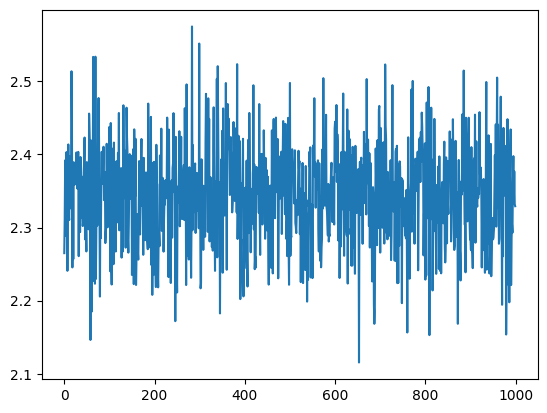

In [47]:
# I was like this is weird... then realized params aren't reinitialized lol

# lrs = [0.1]
# for lr in lrs:
  # with torch.no_grad():
  #   C.copy_(C0)
  #   W1.copy_(W10)
  #   b1.copy_(b10)
  #   W2.copy_(W20)
  #   b2.copy_(b20)
  # for p in params:
  #   p.grad = None
stepi = []
lossi = []
for i in range(1000):
  stepi.append(i)
  # Take small batch
  ix = torch.randint(len(Xtr), (batchsize,))

  # Forward pass
  Xtr[ix].shape
  C[Xtr[ix]].shape

  # .view() is the most efficient way to reformat a tensor
  logits = (torch.tanh(C[Xtr[ix]].view(-1,cwin * edim) @ W1 + b1)) @ W2 + b2
  # F.cross_entropy is more efficient and numerically stable than hand-computing losses
  loss = F.cross_entropy(logits, Ytr[ix])
  loss.item()

  # Backprop
  for p in params:
    p.grad = None
  loss.backward()
  for p in params:
    p.data -= 0.01 * p.grad

  lossi.append(loss.item())
  # plt.figure()
plt.plot(stepi, lossi)
  # lr_val.append(lr)
  # lr_loss.append(lossi[-1])
# plt.figure()
# plt.plot(lr_val, lr_loss)

In [48]:
# Compute val, train loss
with torch.no_grad():
  print(F.cross_entropy(torch.tanh((C[Xval]).view(-1,cwin * edim) @ W1 + b1) @ W2 + b2, Yval))
  print(F.cross_entropy(torch.tanh((C[Xtest]).view(-1,cwin * edim) @ W1 + b1) @ W2 + b2, Ytest))

tensor(2.3357)
tensor(2.3482)


In [58]:
# Finally, sampling!
for _ in range(20):
  init = [0] * cwin
  output = []
  while (True):
    probs = F.softmax(torch.tanh(C[init].view(-1) @ W1 + b1) @ W2 + b2, dim=0)
    ix = torch.multinomial(probs, num_samples=1, replacement=True).item()
    init = init[1:] + [ix]
    output.append(ix)
    if (ix == 0):
      break
  print(''.join(itos[x] for x in output))

ellalen.
jutarreri.
eleo.
bicorellys.
haretondanellyn.
dren.
jayepkaransh.
juyan.
darnila.
radimriqu.
dodeliar.
sorallit.
lylo.
kasa.
brunziefi.
amtin.
ivisto.
man.
cadoite.
eld.
